# ZOIB Regression

In this example, we model and predict all parameters of a univariate **Zero-One Inflated Beta (ZOIB)** distribution. Recall that distributional regression models and predicts all $K$ parameters $\theta_{ik}, k=1, \ldots, K$ of a distribution $\mathcal{D}$ as a function of covariates:

$$
y_{i} \stackrel{ind}{\sim} \mathcal{D}
  \begin{pmatrix}
     h_{1}\bigl(\theta_{i1}(x_{i})\bigr) = \eta_{i1} \\
    h_{2}\bigl(\theta_{i2}(x_{i})\bigr) = \eta_{i2}  \\ 
  \vdots \\                        
  h_{K}\bigl(\theta_{iK}(x_{i})\bigr) = \eta_{iK} 
\end{pmatrix}
\quad  ,i=1, \ldots, N. 
$$

where $h_{k}(\cdot)$ transforms each distributional parameter to the valid parameter scale. 

For the univariate ZOIB case, the distribution handles values in the closed interval $[0, 1]$, making it ideal for proportions or fractional targets (like Loss Given Default) that contain exact zeros and exact ones. We specify the model as:

$$
y_{i} \stackrel{ind}{\sim} \text{ZOIB}\bigl(\mu_{i}(x_{i}), \phi_{i}(x_{i}), p_{zi}(x_{i}), p_{oi}(x_{i})\bigr)
$$

The four parameters are mapped to their valid ranges using specific response functions $h_{k}(\cdot)$:

1.  **$\mu_{i}(x_{i})$ (Mean of the Beta distribution):** Since the continuous fraction must fall strictly within $(0, 1)$, $h_1$ is typically the **sigmoid** (or logistic) function.
2.  **$\phi_{i}(x_{i})$ (Precision of the Beta distribution):** Since the precision must be strictly positive ($\phi > 0$), $h_2$ is typically the **exponential** or **softplus** function.
3.  **$p_{zi}(x_{i})$ (Probability of an exact 0 or 1):** Also called `gate_zo`, this is a probability that must fall in $[0, 1]$, so $h_3$ is the **sigmoid** function.
4.  **$p_{oi}(x_{i})$ (Conditional probability of an exact 1):** Also called `gate_one`, this is the probability of the value being exactly 1 *given* that it is discrete. It must fall in $[0, 1]$, so $h_4$ is also the **sigmoid** function.

# Imports

In [28]:
from xgboostlss.model import *
from xgboostlss.distributions.ZOIB import *
from xgboostlss.datasets.data_loader import load_simulated_ZOIB_data

from sklearn.metrics import mean_squared_error, mean_absolute_error, roc_auc_score
import numpy as np
import pandas as pd
import multiprocessing
from plotnine import *

plotnine.options.figure_size = (18, 9)
n_cpu = multiprocessing.cpu_count()

# Data

In [29]:
train, test = load_simulated_ZOIB_data()
n_cpu = multiprocessing.cpu_count()

X_train, y_train = train.drop(columns=["lgd"]), train["lgd"].values
X_test, y_test = test.drop(columns=["lgd"]), test["lgd"].values

dtrain = xgb.DMatrix(X_train, label=y_train, nthread=n_cpu)
dtest = xgb.DMatrix(X_test, nthread=n_cpu)

# Model Specification

In [30]:
xgblss = XGBoostLSS(
    ZOIB(stabilization="None",  
             response_fn="softplus",      
             loss_fn="nll"          
            )
)

# Hyper-Parameter Optimization

Any XGBoost hyperparameter can be tuned, where the structure of the parameter dictionary needs to be as follows:

    - Float/Int sample_type
        - {"param_name": ["sample_type", low, high, log]}
            - sample_type: str, Type of sampling, e.g., "float" or "int"
            - low: int, Lower endpoint of the range of suggested values
            - high: int, Upper endpoint of the range of suggested values
            - log: bool, Flag to sample the value from the log domain or not
        - Example: {"eta": "float", low=1e-5, high=1, log=True]}

    - Categorical sample_type
        - {"param_name": ["sample_type", ["choice1", "choice2", "choice3", "..."]]}
            - sample_type: str, Type of sampling, either "categorical"
            - choice1, choice2, choice3, ...: str, Possible choices for the parameter
        - Example: {"booster": ["categorical", ["gbtree", "dart"]]}

    - For parameters without tunable choice (this is needed if tree_method = "gpu_hist" and gpu_id needs to be specified)
        - {"param_name": ["none", [value]]},
            - param_name: str, Name of the parameter
            - value: int, Value of the parameter
        - Example: {"gpu_id": ["none", [0]]}

Depending on which parameters are optimized, it might happen that some of them are not used, e.g., when {"booster":  ["categorical", ["gbtree", "gblinear"]]} and {"max_depth": ["int", 1, 10, False]} are specified, max_depth is not used when gblinear is sampled, since it has no such argument.

In [31]:
param_dict = {
    "eta":              ["float", {"low": 1e-5,   "high": 1,     "log": True}],
    "max_depth":        ["int",   {"low": 1,      "high": 10,    "log": False}],
    "gamma":            ["float", {"low": 1e-8,   "high": 40,    "log": True}],
    "subsample":        ["float", {"low": 0.2,    "high": 1.0,   "log": False}],
    "colsample_bytree": ["float", {"low": 0.2,    "high": 1.0,   "log": False}],
    "min_child_weight": ["float", {"low": 1e-8,   "high": 500,   "log": True}],
    "booster":          ["categorical", ["gbtree"]]
}

np.random.seed(123)
opt_param = xgblss.hyper_opt(param_dict,
                             dtrain,
                             num_boost_round=100,        # Number of boosting iterations.
                             nfold=5,                    # Number of cv-folds.
                             early_stopping_rounds=20,   # Number of early-stopping rounds
                             max_minutes=15,             # Time budget in minutes, i.e., stop study after the given number of minutes.
                             n_trials=30 ,               # The number of trials. If this argument is set to None, there is no limitation on the number of trials.
                             silence=False,              # Controls the verbosity of the trail, i.e., user can silence the outputs of the trail.
                             seed=123,                   # Seed used to generate cv-folds.
                             hp_seed=123                 # Seed for random number generator used in the Bayesian hyperparameter search.
                            )

[I 2026-05-14 17:51:35,007] A new study created in memory with name: XGBoostLSS Hyper-Parameter Optimization


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-05-14 17:52:13,048] Trial 0 finished with value: 346.4920164 and parameters: {'eta': 0.030363087280807707, 'max_depth': 3, 'gamma': 1.5074442732613943e-06, 'subsample': 0.6410518152663129, 'colsample_bytree': 0.7755751758284506, 'min_child_weight': 0.00033635921133357536, 'booster': 'gbtree'}. Best is trial 0 with value: 346.4920164.
[I 2026-05-14 17:52:28,956] Trial 1 finished with value: -233.8414612 and parameters: {'eta': 0.8013476947482925, 'max_depth': 7, 'gamma': 0.0004148938237251032, 'subsample': 0.5136940145553204, 'colsample_bytree': 0.47454241292069554, 'min_child_weight': 0.6310749636830225, 'booster': 'gbtree'}. Best is trial 1 with value: -233.8414612.
[I 2026-05-14 17:53:02,099] Trial 2 finished with value: 4232.928222799999 and parameters: {'eta': 0.0015590542353378792, 'max_depth': 1, 'gamma': 6.638115717563432e-05, 'subsample': 0.7903963245856287, 'colsample_bytree': 0.3459933843628, 'min_child_weight': 7.536211465592933e-07, 'booster': 'gbtree'}. Best is tri

# Model Training

In [32]:
np.random.seed(123)

opt_params = opt_param.copy()
n_rounds = opt_params["opt_rounds"]
del opt_params["opt_rounds"]

# Train Model with optimized hyperparameters
xgblss.train(opt_params,
             dtrain,
             num_boost_round=n_rounds
             )

# Prediction


In [33]:
# Set seed for reproducibility
torch.manual_seed(123)

# Number of samples to draw from predicted distribution
n_samples = 1000
quant_sel = [0.05, 0.95] # Quantiles to calculate from predicted distribution

# Sample from predicted distribution
pred_samples = xgblss.predict(dtest,
                              pred_type="samples",
                              n_samples=n_samples,
                              seed=123)

# Calculate quantiles from predicted distribution
pred_quantiles = xgblss.predict(dtest,
                                pred_type="quantiles",
                                n_samples=n_samples,
                                quantiles=quant_sel)

# Return predicted distributional parameters
pred_params = xgblss.predict(dtest,
                             pred_type="parameters")

In [34]:
pred_samples.head()

,y_sample0,y_sample1,y_sample2,y_sample3,y_sample4,y_sample5,y_sample6,y_sample7,y_sample8,y_sample9,...,y_sample990,y_sample991,y_sample992,y_sample993,y_sample994,y_sample995,y_sample996,y_sample997,y_sample998,y_sample999
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,0.918488,1.000000,0.896969,0.852366,0.831108,1.000000,0.907755,0.946898,0.921673,0.854512,...,0.969717,1.000000,0.913541,0.885531,0.876417,0.917904,0.892725,0.948474,0.887947,0.890604
3,0.968594,0.977058,0.962341,0.941013,0.953021,0.980567,0.965721,0.943594,0.960569,0.905873,...,0.990333,0.983991,0.963517,0.957149,0.964660,0.973403,0.960444,0.958382,0.963103,0.977490
4,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,0.824948,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [35]:
pred_quantiles.head()

,quant_0.05,quant_0.95
0,0.000000,0.000000
1,0.866983,1.000000
2,0.801385,1.000000
3,0.907381,0.998046
4,0.832606,1.000000


In [36]:
pred_params.head()

,mu,phi,gate_zo,gate_one
0,0.061325,20.221403,0.966106,0.001000
1,0.800611,34.511063,0.942130,0.999000
2,0.882681,49.788113,0.155809,0.998491
3,0.963800,43.387833,0.034618,0.999000
4,0.811207,33.826576,0.906854,0.999000


# Actual vs. Predicted


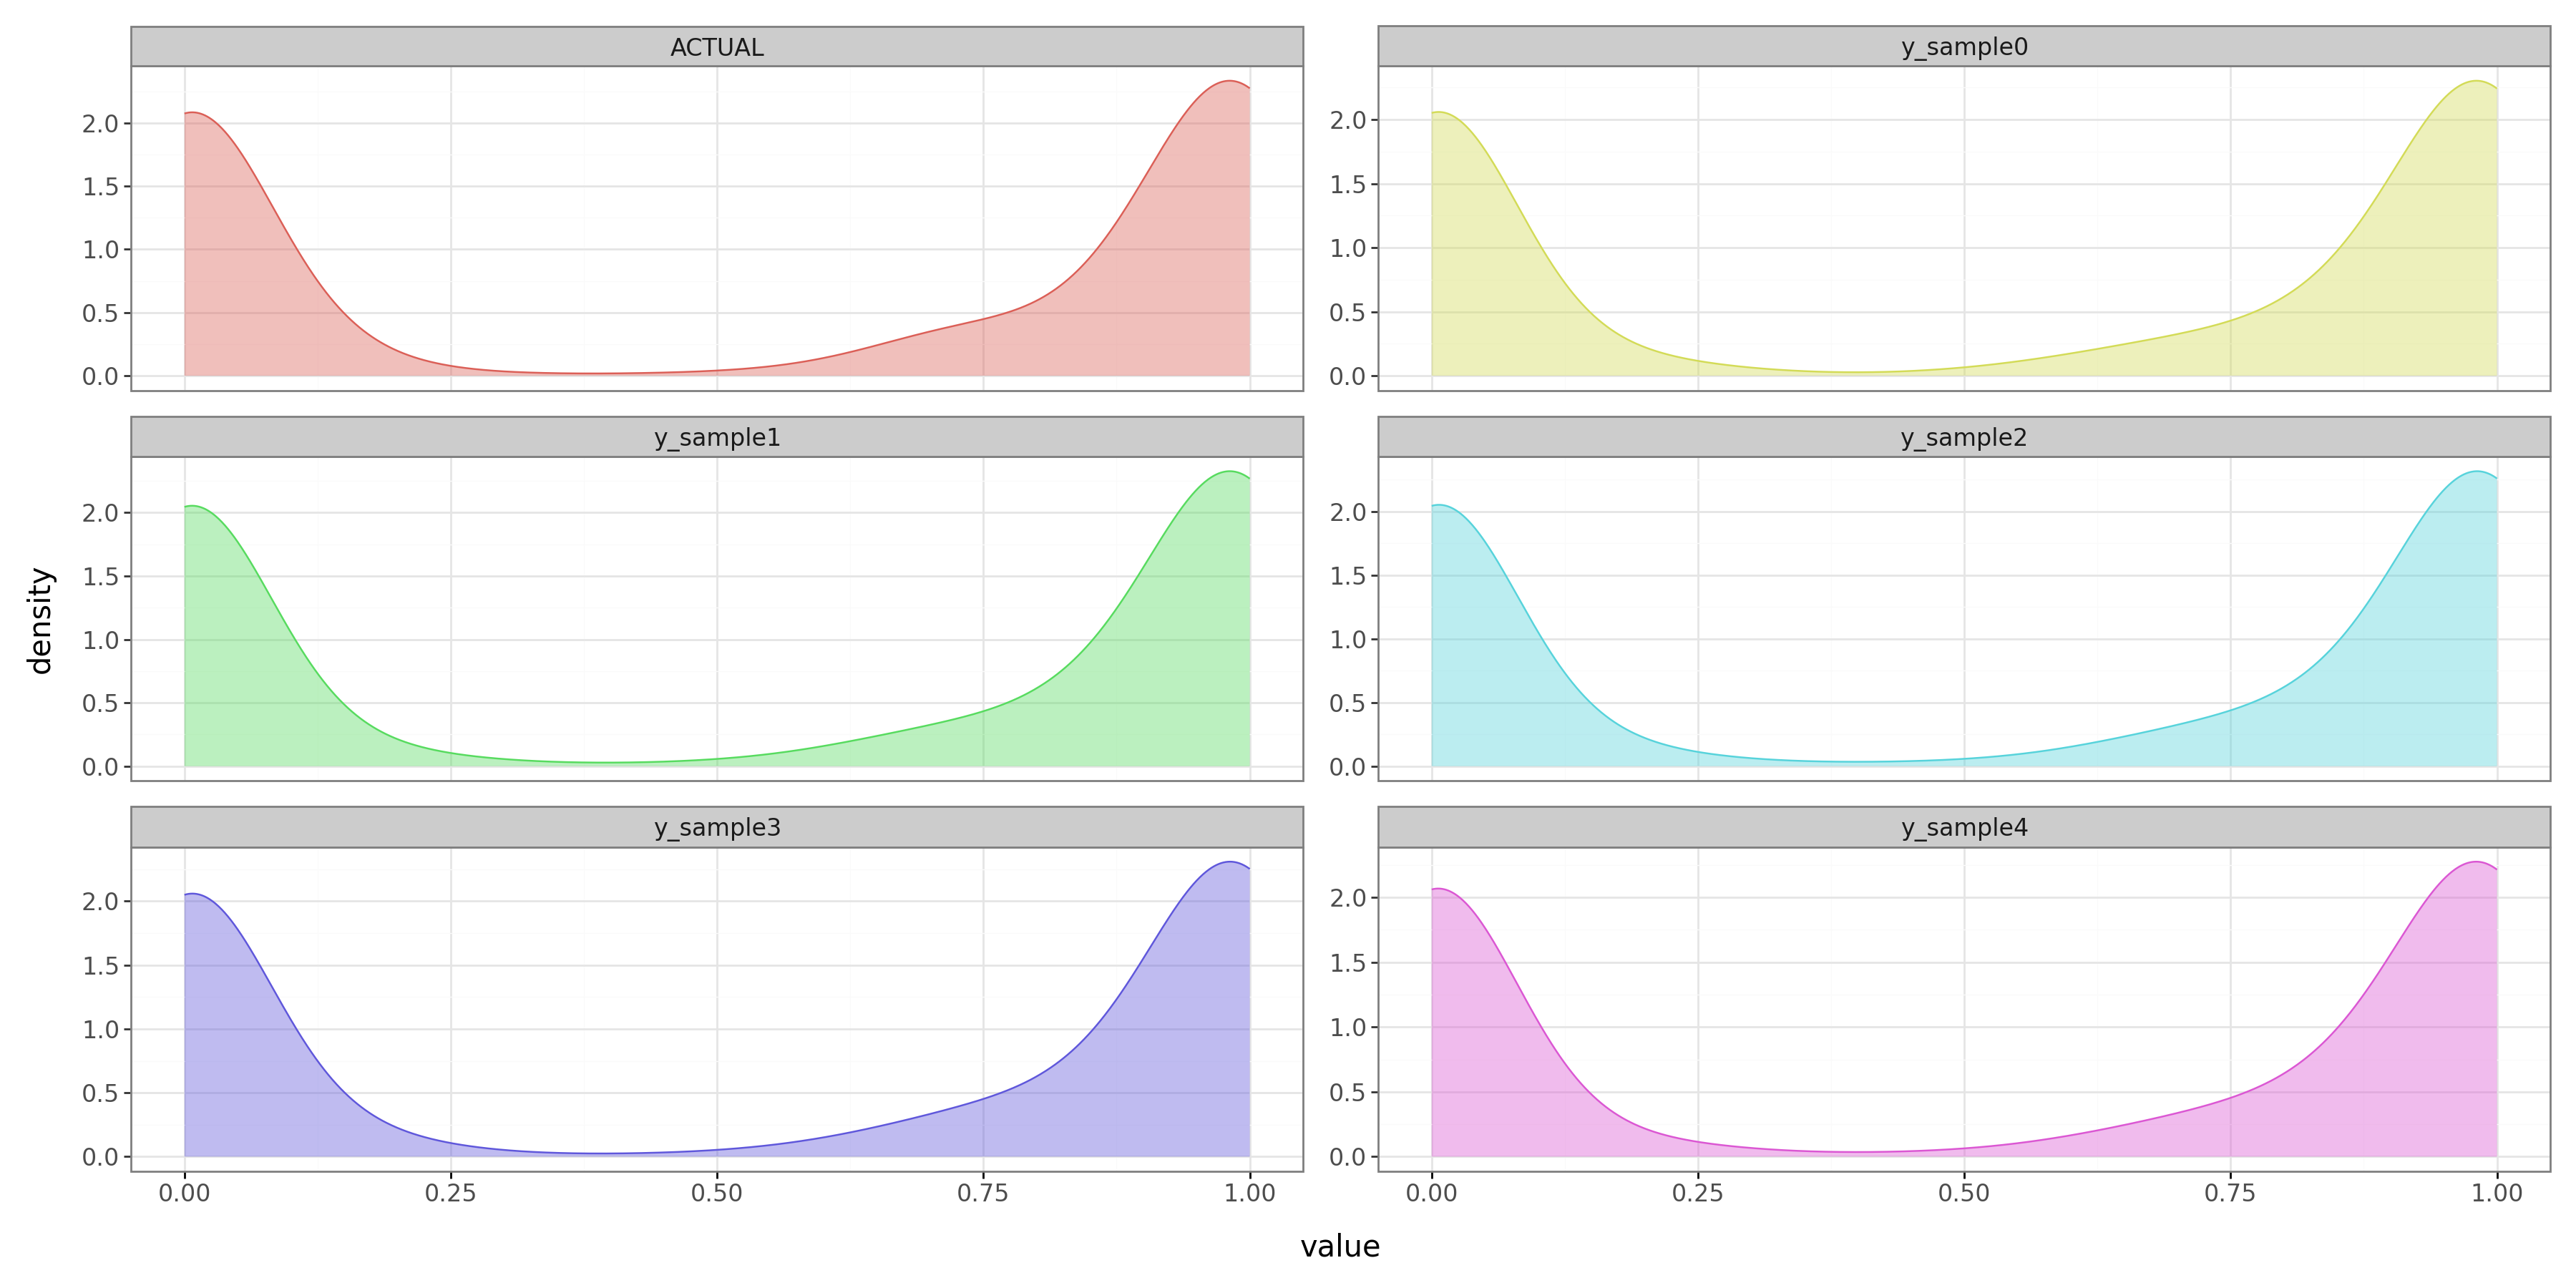

In [37]:
pred_df = pd.melt(pred_samples.iloc[:,0:5])
actual_df = pd.DataFrame.from_dict({"variable": "ACTUAL", "value": y_test.reshape(-1,)})
plot_df = pd.concat([pred_df, actual_df])

(
    ggplot(plot_df, 
           aes(x="value",
               color="variable",
               fill="variable")) +  
    geom_density(alpha=0.4) + 
    facet_wrap("variable",
              scales="free_y",
              ncol=2) + 
    theme_bw(base_size=15) + 
    theme(legend_position="none")
)

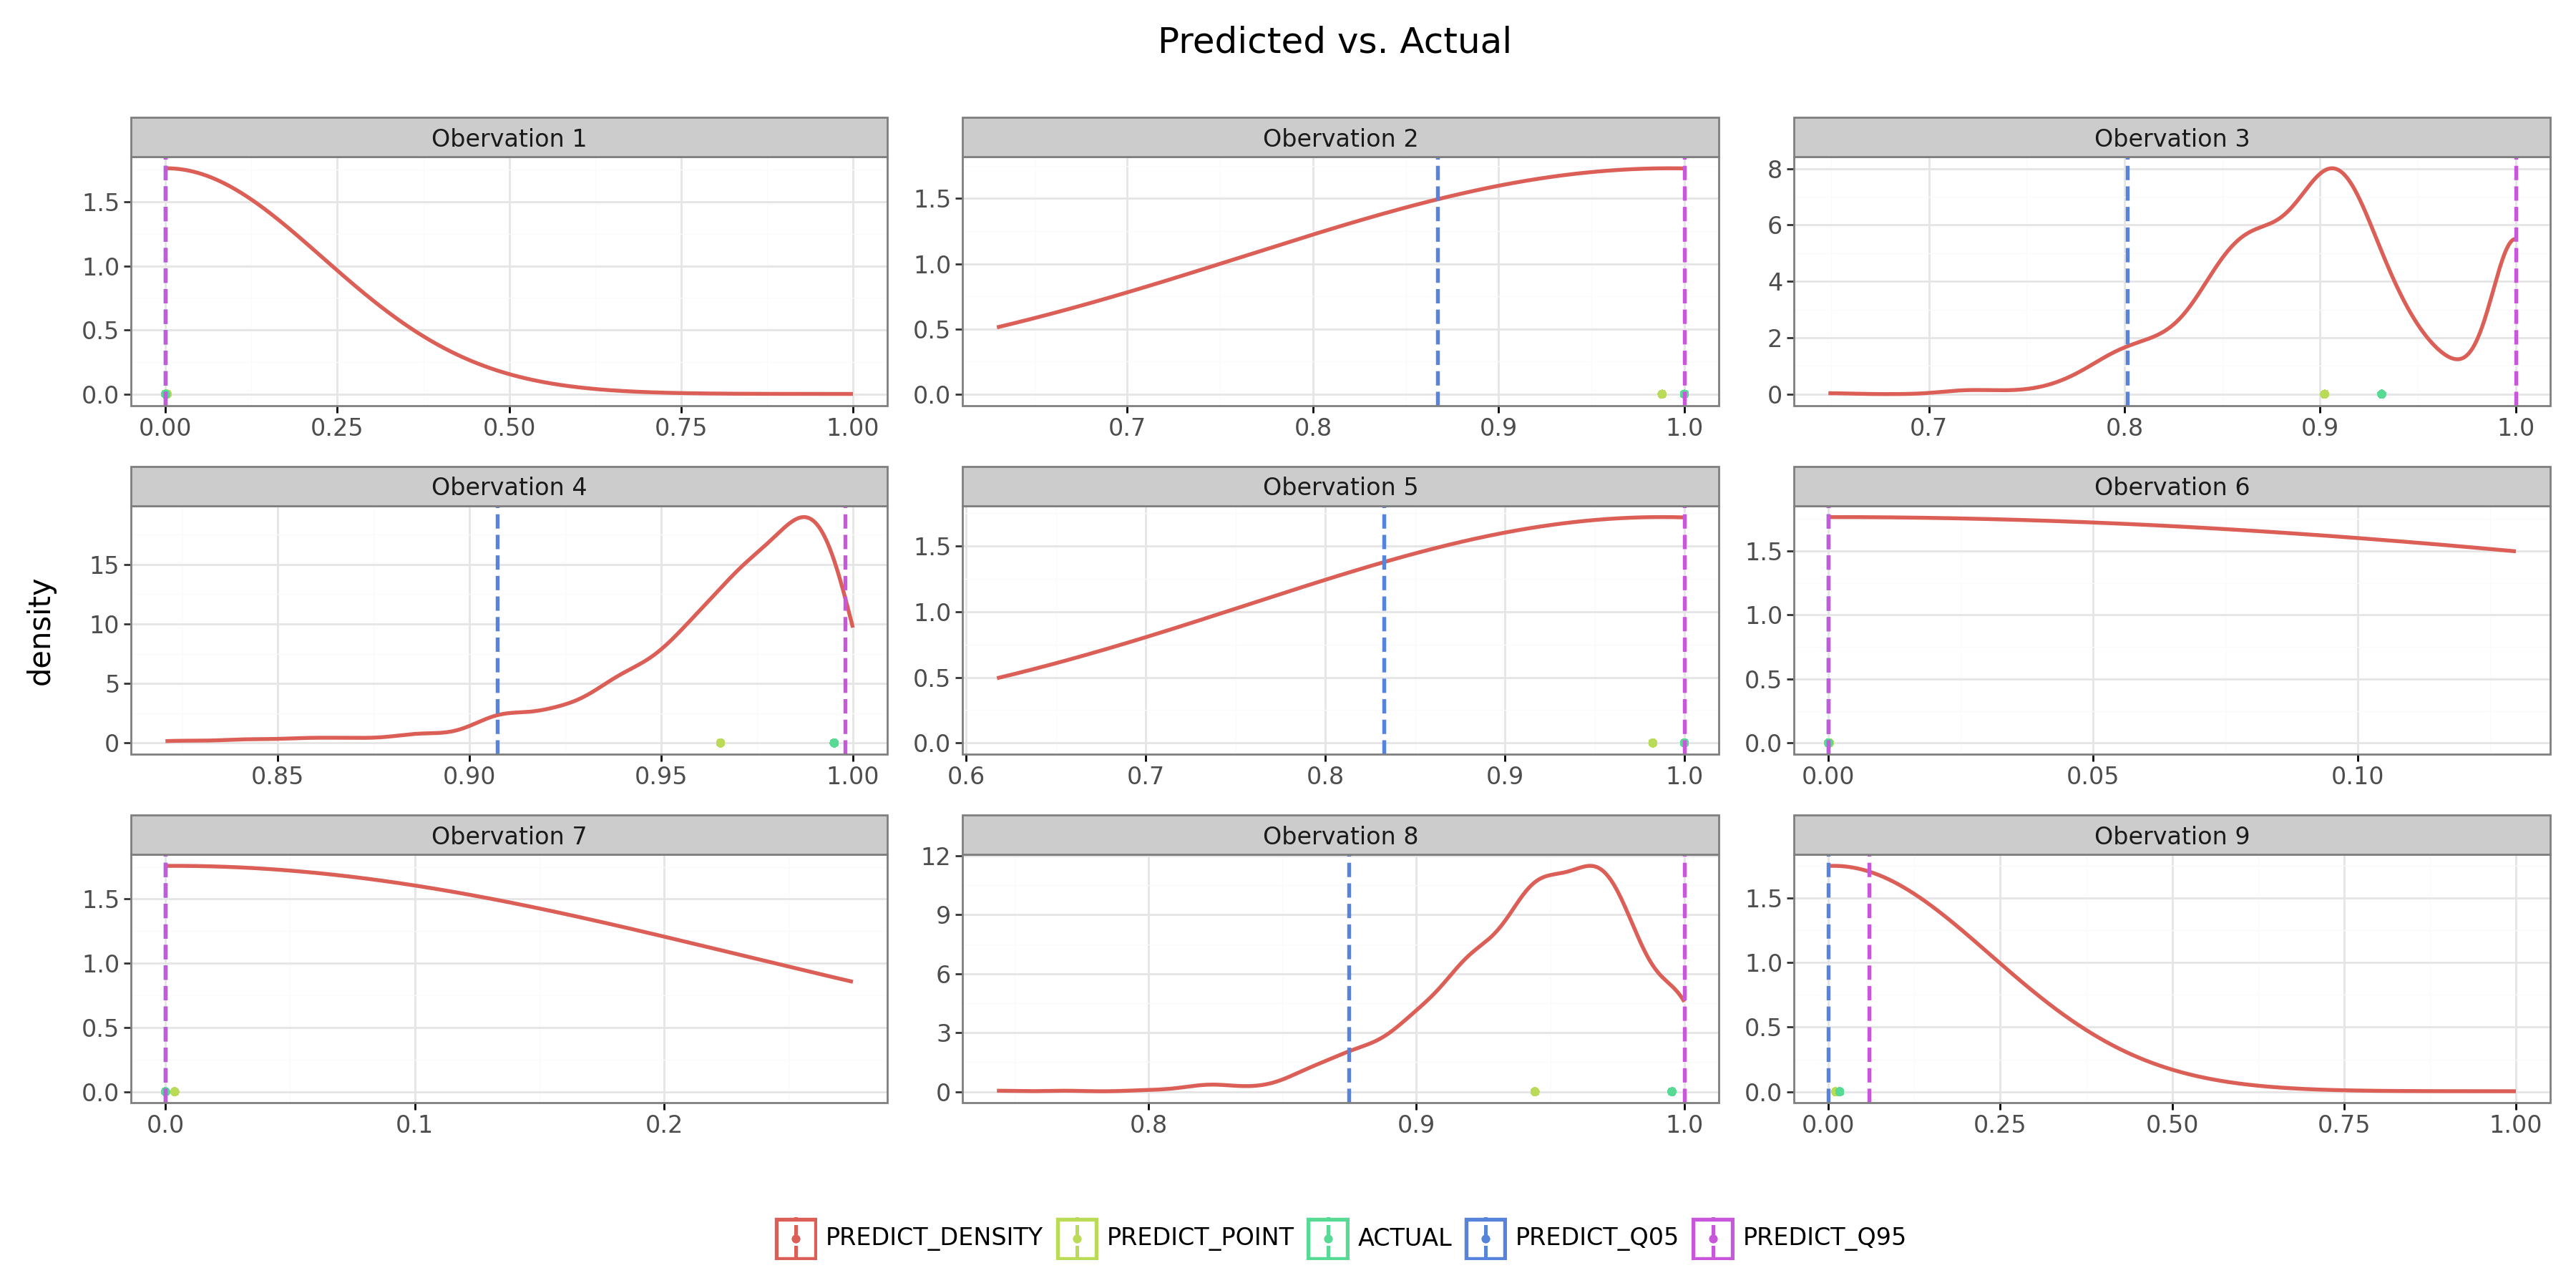

In [38]:
y_pred = []

n_examples = 9

for i in range(n_examples):    
    y_samples = pd.DataFrame(pred_samples.values[i,:].reshape(-1,1), columns=["PREDICT_DENSITY"])
    y_samples["PREDICT_POINT"] = y_samples["PREDICT_DENSITY"].mean()
    y_samples["PREDICT_Q05"] = y_samples["PREDICT_DENSITY"].quantile(q=quant_sel[0])
    y_samples["PREDICT_Q95"] = y_samples["PREDICT_DENSITY"].quantile(q=quant_sel[1])
    y_samples["ACTUAL"] = y_test[i]
    y_samples["obs"]= f"Obervation {i+1}"
    y_pred.append(y_samples)
    
pred_df = pd.melt(pd.concat(y_pred, axis=0), id_vars="obs")
pred_df["obs"] = pd.Categorical(pred_df["obs"], categories=[f"Obervation {i+1}" for i in range(n_examples)])
df_actual, df_pred_dens, df_pred_point, df_q05, df_q95 = [x for _, x in pred_df.groupby("variable")]

plot_pred = (
    ggplot(pred_df,
           aes(color="variable")) + 
    stat_density(df_pred_dens,
                 aes(x="value"),
                 size=1.1) + 
    geom_point(df_pred_point,
               aes(x="value",
                   y=0),
               size=1.4) + 
    geom_point(df_actual,
               aes(x="value",
                   y=0),
               size=1.4) + 
    geom_vline(df_q05, 
               aes(xintercept="value",
                   fill="variable",
                   color="variable"),
               linetype="dashed",
               size=1.1) + 
    geom_vline(df_q95, 
               aes(xintercept="value",
                   fill="variable",
                   color="variable"),
               linetype="dashed",
               size=1.1) + 
    facet_wrap("obs",
               scales="free",
               ncol=3) + 
    labs(title="Predicted vs. Actual \n",
         x = "") + 
    theme_bw(base_size=15) +
    scale_fill_brewer(type="qual", palette="Dark2") + 
    theme(legend_position="bottom",
          plot_title = element_text(hjust = 0.5),
          legend_title = element_blank()
         )
)

plot_pred.show()

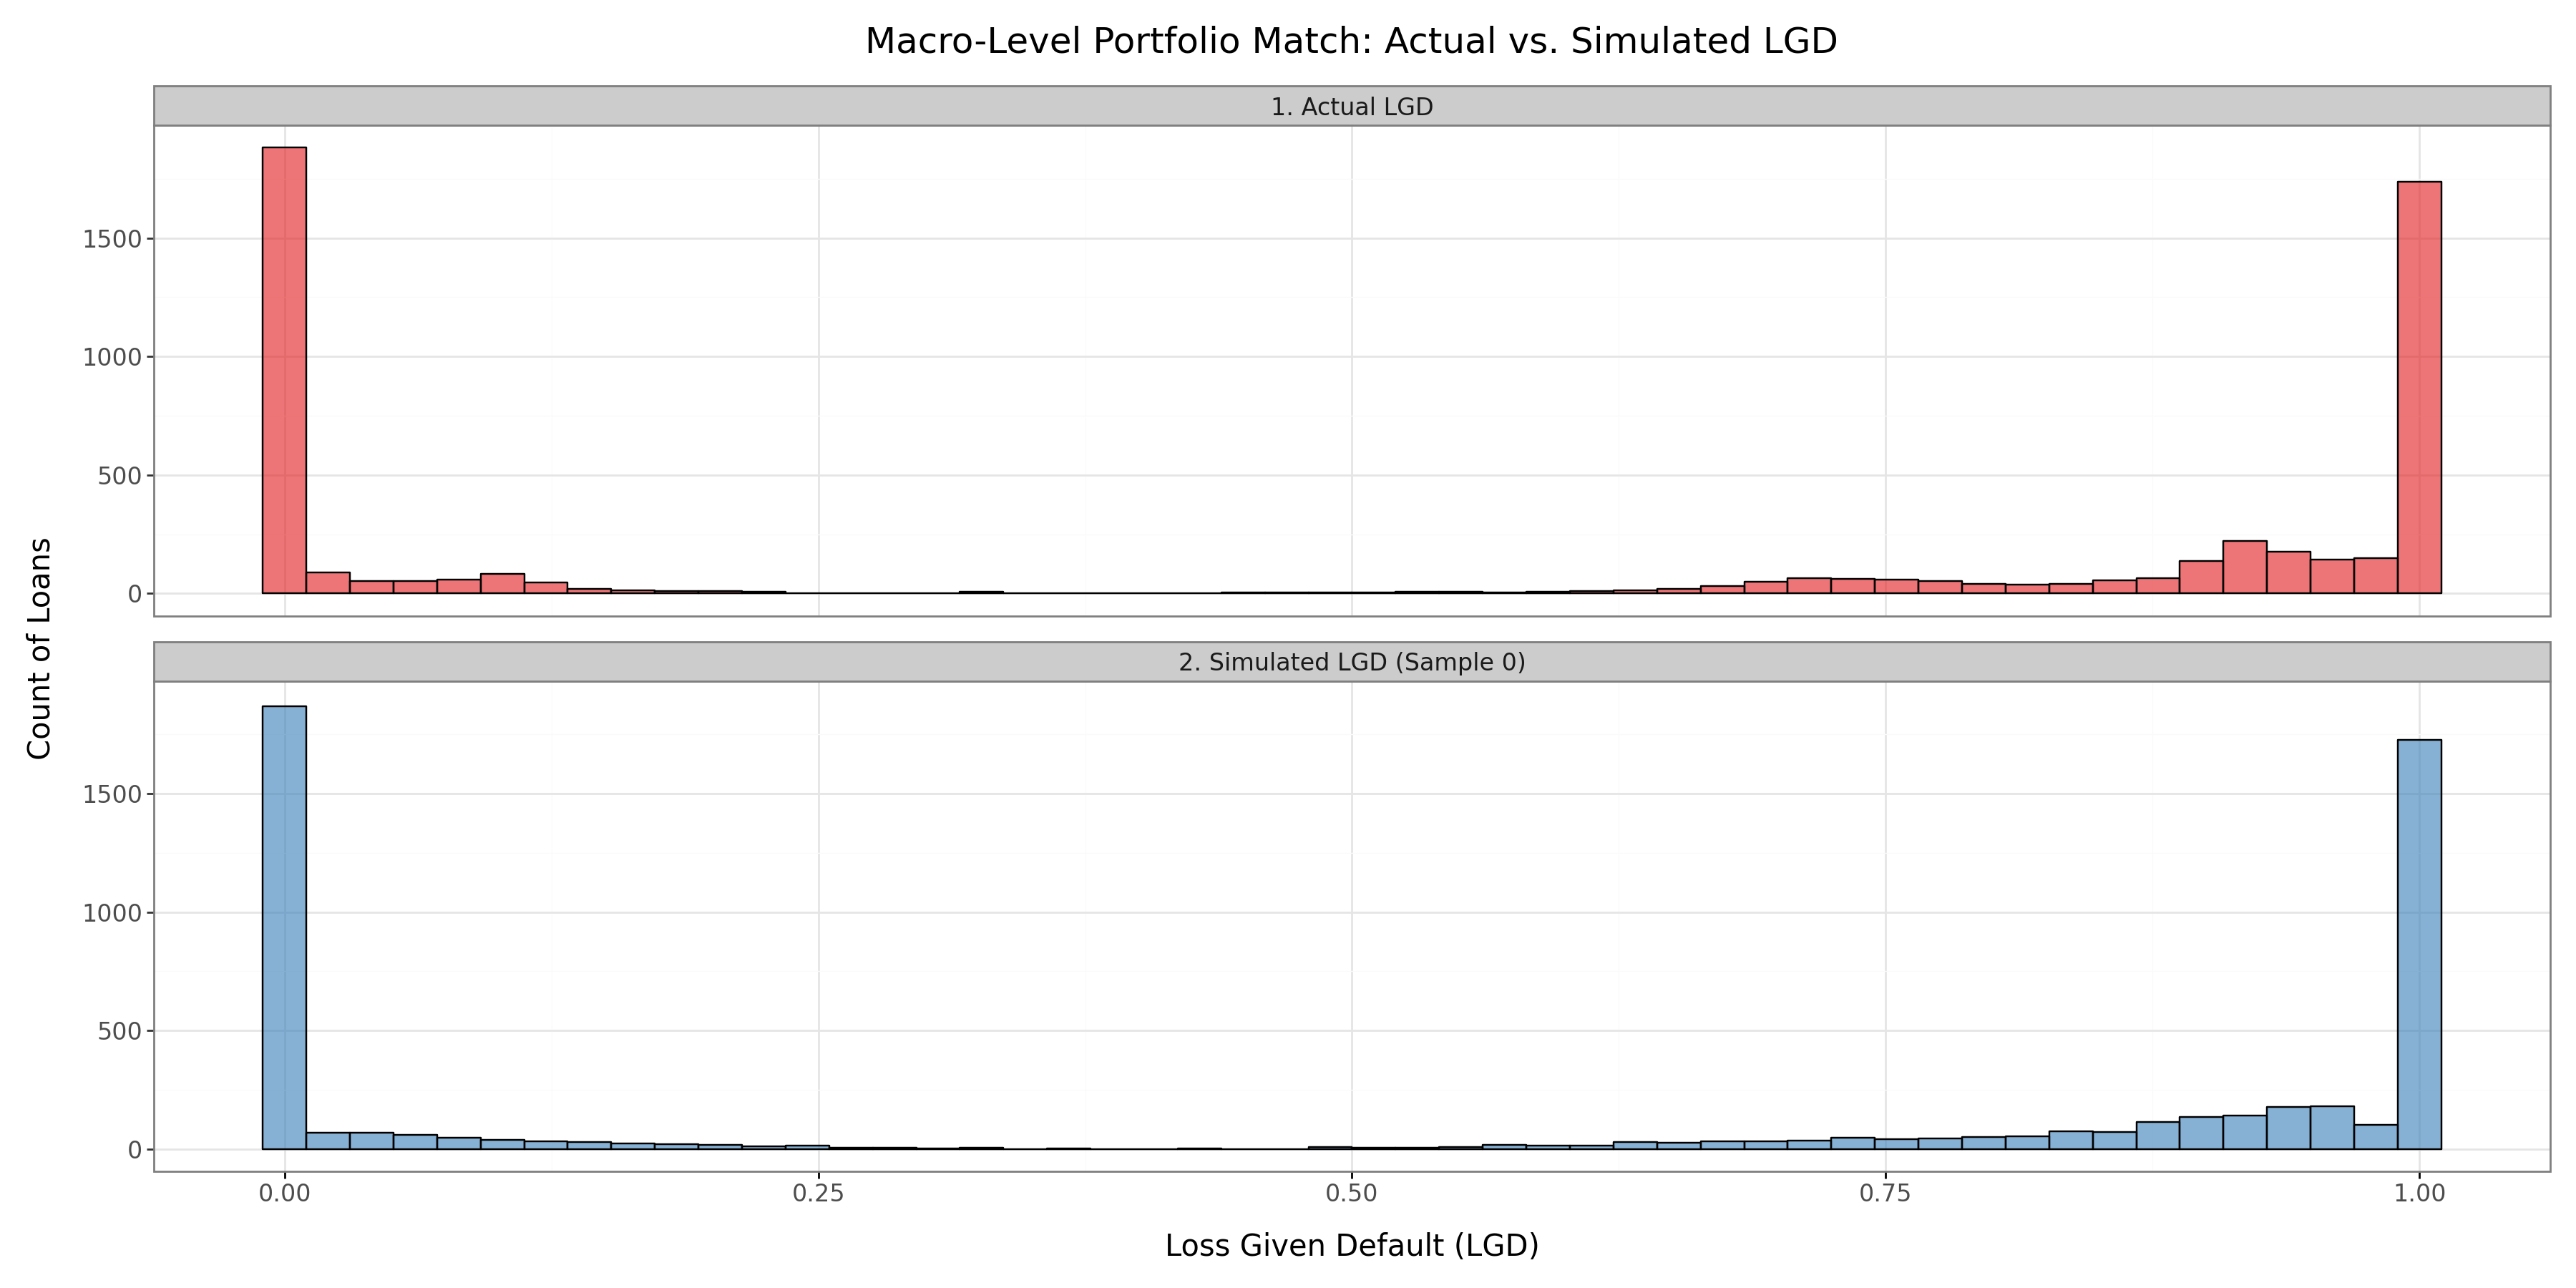

In [ ]:
df_macro = pd.DataFrame({
    "1. Actual LGD": y_test,
    "2. Simulated LGD (Sample 0)": pred_samples.iloc[:, 0].values
})
df_macro_melt = pd.melt(df_macro, var_name="Distribution", value_name="LGD")

plot_macro = (
    ggplot(df_macro_melt, aes(x="LGD", fill="Distribution")) +
    geom_histogram(alpha=0.6, position="identity", bins=50, color="black") +
    facet_wrap("~ Distribution", ncol=1) + 
    labs(
        title="Macro-Level Portfolio Match: Actual vs. Simulated LGD",
        x="Loss Given Default (LGD)",
        y="Count of Loans"
    ) +
    theme_bw(base_size=15) +
    scale_fill_brewer(type="qual", palette="Set1") +
    theme(legend_position="none", plot_title=element_text(hjust=0.5))
)

plot_macro.show()

# Interpretability

<Figure size 1000x800 with 0 Axes>

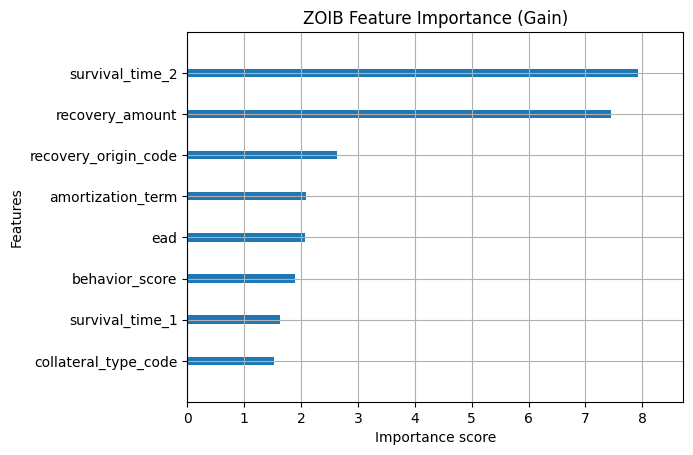

In [ ]:
import matplotlib.pyplot as plt
import xgboost as xgb

booster = xgblss.booster

plt.figure(figsize=(10, 8))
xgb.plot_importance(booster, 
                    importance_type='gain', 
                    max_num_features=10, 
                    title="ZOIB Feature Importance (Gain)",
                    show_values=False)
plt.show()

# Metrics

In [41]:
# 1. Compute Mean Metrics
# The expected LGD is the average of the 1,000 Monte Carlo samples for each row
y_expected = pred_samples.mean(axis=1).values
rmse = np.sqrt(mean_squared_error(y_test, y_expected))
mae = mean_absolute_error(y_test, y_expected)

# 2. Compute Gate Metrics (How well did the model separate the 0s and 1s?)
is_zero = (y_test == 0).astype(int)
is_one = (y_test == 1).astype(int)

# gate_zo is the probability of being 0 or 1. 
# gate_one is the conditional probability of being 1 given it is discrete.
prob_one = pred_params['gate_zo'] * pred_params['gate_one']
prob_zero = pred_params['gate_zo'] * (1 - pred_params['gate_one'])

auc_zero = roc_auc_score(is_zero, prob_zero)
auc_one = roc_auc_score(is_one, prob_one)

print(f"--- Evaluation Metrics ---")
print(f"RMSE (Expected LGD vs Actual LGD): {rmse:.4f}")
print(f"MAE (Expected LGD vs Actual LGD):  {mae:.4f}")
print(f"AUC (Predicting exact 0s):         {auc_zero:.4f}")
print(f"AUC (Predicting exact 1s):         {auc_one:.4f}")

--- Evaluation Metrics ---
RMSE (Expected LGD vs Actual LGD): 0.0898
MAE (Expected LGD vs Actual LGD):  0.0380
AUC (Predicting exact 0s):         0.9829
AUC (Predicting exact 1s):         0.9839


In [42]:
def calculate_crps(y_true, y_samples):
    # Format inputs
    y = np.array(y_true).reshape(-1)
    
    # Transpose samples to shape (n_samples, n_observations)
    yhat_dist = np.array(y_samples).T
    n_samples = yhat_dist.shape[0]

    # Sort the forecasts in ascending order for each observation
    yhat_dist_sorted = np.sort(yhat_dist, axis=0)

    # Initialize tracking arrays
    y_cdf = np.zeros_like(y, dtype=float)
    yhat_cdf = np.zeros_like(y, dtype=float)
    yhat_prev = np.zeros_like(y, dtype=float)
    crps = np.zeros_like(y, dtype=float)

    # Calculate empirical CDF differences
    for yhat in yhat_dist_sorted:
        flag = (y_cdf == 0) & (y < yhat)
        crps += flag * ((y - yhat_prev) * yhat_cdf ** 2)
        crps += flag * ((yhat - y) * (yhat_cdf - 1) ** 2)
        crps += (~flag) * ((yhat - yhat_prev) * (yhat_cdf - y_cdf) ** 2)
        y_cdf += flag
        yhat_cdf += 1 / n_samples
        yhat_prev = yhat

    # In case actual y is greater than all predicted samples
    flag = (y_cdf == 0)
    crps += flag * (y - yhat_prev)

    return crps.mean()

mean_crps = calculate_crps(y_test, pred_samples.values)
print(f"Mean CRPS: {mean_crps:.4f}")

Mean CRPS: 0.0227
